# PV Forecasting — 2. Data Quality Check & Feature Engineering

**Purpose:** quantify missingness, sanity-check the power readings, and derive the time-based features (`hour`, `month`, `day_of_year`, `is_daylight`) used throughout the rest of the pipeline.

**Input:** `../Output/checkpoint_01_loaded.pkl`

**Output:** `../Output/checkpoint_02_quality.pkl` — used by notebooks 3, 4, and 5

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "../Output"

In [2]:
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_01_loaded.pkl")
df.shape

(5832, 26)

## 3. Data quality check

### 3.1 Missing values per column

Note: `PV1/PV2_Power_W` are null at night because there's no sun. What matters is missingness *during daylight hours*.

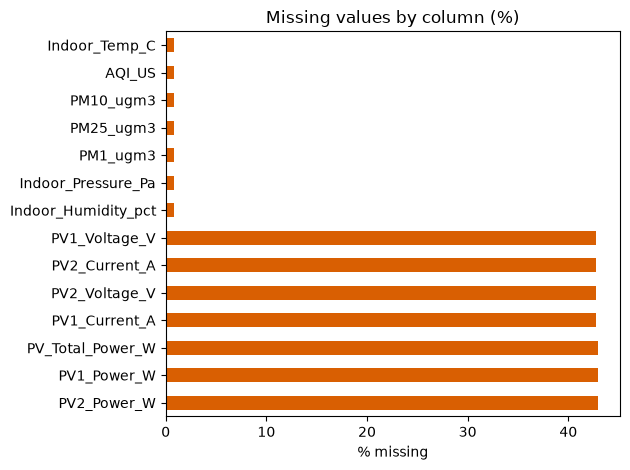

PV2_Power_W            42.986968
PV1_Power_W            42.986968
PV_Total_Power_W       42.986968
PV1_Current_A          42.729767
PV2_Voltage_V          42.729767
PV2_Current_A          42.729767
PV1_Voltage_V          42.729767
Indoor_Humidity_pct     0.805898
Indoor_Pressure_Pa      0.805898
PM1_ugm3                0.805898
PM25_ugm3               0.805898
PM10_ugm3               0.805898
AQI_US                  0.805898
Indoor_Temp_C           0.805898
dtype: float64

In [3]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values remain.")
else:
    missing_pct.plot(kind="barh", color="#d95f02", title="Missing values by column (%)")
    plt.xlabel("% missing")
    plt.tight_layout()
    plt.show()

missing_pct

In [4]:
is_night = df["Solar_Radiation_Wm2"] == 0

print(f"PV_Total_Power_W missing at night:   {df.loc[is_night, 'PV_Total_Power_W'].isna().mean()*100:.1f}%")
print(f"PV_Total_Power_W missing in daylight: {df.loc[~is_night, 'PV_Total_Power_W'].isna().mean()*100:.1f}%")

PV_Total_Power_W missing at night:   95.2%
PV_Total_Power_W missing in daylight: 7.6%


### 3.2 Sanity check

In [5]:
print("Negative PV power readings:", (df["PV_Total_Power_W"] < 0).sum())

Negative PV power readings: 0


### 3.3 Feature engineering

In [6]:
df["hour"] = df["Timestamp"].dt.hour
df["month"] = df["Timestamp"].dt.month
df["day_of_year"] = df["Timestamp"].dt.dayofyear
df["is_daylight"] = (df["Solar_Radiation_Wm2"] > 0).astype(int)

## Handoff
Save a checkpoint with the engineered features for the correlation, visual-inspection, and data-preparation notebooks.

In [7]:
df.to_pickle(f"{OUTPUT_DIR}/checkpoint_02_quality.pkl")
print("Saved checkpoint_02_quality.pkl —", df.shape)

Saved checkpoint_02_quality.pkl — (5832, 30)
